# Measuring Educational Opportunity: Proxy Definitions, Participation Indicators, and Denominator Divergence
### A Disciplined Empirical Measurement Study of Missouri High Schools (2021–22 CRDC & NCES CCD)
**Computational Sketchbook: Education Policy & Measurement Observatory**  
*Data Sources: U.S. Department of Education Office for Civil Rights (OCR) Civil Rights Data Collection (CRDC 2021–22) and National Center for Education Statistics (NCES) Common Core of Data (CCD 2021–22 Directory).*

---

## Executive Summary & Problem Formulation

When education researchers and state agencies measure advanced academic opportunity, they rely on administrative survey indicators:
- *"Does a school offer Advanced Placement (AP)?"*
- *"Do students have access to specialized STEM coursework like Physics or Computer Science?"*

However, empirical measurement routinely breaks down across three distinct vulnerabilities:
1. **Indicator Interpretation**: Survey items often measure reported *student participation/enrollment* during a specific collection year rather than institutional *course offerings* in a curriculum guide, changing what research questions can be credibly answered.
2. **Proxy Blind Spots**: Relying solely on an AP participation indicator blinds researchers to parallel institutional pathways (such as Dual Enrollment and dual credit partnerships).
3. **Denominator Divergence**: Reporting unweighted institutional availability (*"a third of high schools report no physics classes"*) describes a fundamentally different population than reporting student exposure (*"less than a fifth of students attend those schools"*), because course offerings scale systematically with school enrollment size.

This notebook establishes an auditable, six-point admission rule for measurement studies and executes three strictly bounded empirical analyses across Missouri's 2021–22 public high schools.


## 1. Epistemic Philosophy: The Six-Point Study Admission Gate

Before specifying regressions or estimating causal parameters, empirical inquiry requires disciplined measurement. We enforce the following **Six-Point Study Admission Gate**:

1. **Retrieval & Usability**: The underlying administrative records are retrieved, and the required fields contain audited, usable values.
2. **Fixed Population & Denominator**: The population boundaries, exclusions, and denominators are fixed in code and narrative prior to analysis.
3. **Written Mathematical Model**: The calculation or statistical estimator is written down explicitly.
4. **Directional Neutrality**: A result of any direction—including no difference or an unexpected null—substantively answers the question.
5. **Audited Sensitivity Check**: Remaining structural uncertainty (such as conflicting inter-agency reporting or administrative data suppression) is bounded by a specified sensitivity check.
6. **Scholarly & Survey Integrity**: The exact contribution is checked against prior literature and official survey documentation.

### Research Stage Demarcation

| Stage | Goal | Machinery | Role of Regressions / CIs |
| :--- | :--- | :--- | :--- |
| **Stage 1: Measurement Study** *(This Work)* | Measure how proxy definitions, exclusions, and denominators alter reality | Direct counts, cross-tabulations, conditional rates, percentage-point difference wedges | **None needed.** Uncertainty stems from reporting accuracy, exclusions, and survey definitions—not sampling error. |
| **Stage 2: Association Study** | Measure demographic sorting and institutional correlates | Stratified tabulations, multivariate regressions, Shapley decompositions | Requires explicit pre-registration of comparison groups and model controls. |
| **Stage 3: Causal Effect Study** | Estimate policy impacts on student learning or adult wages | Quasi-experimental designs, regression discontinuities, lottery controls | Feasible only when a credible exogenous identification strategy exists. |


## 2. Environment Setup & Data Ingestion

We load the standardized Missouri High School CRDC Measurement Panel constructed by `src/build_panel.py`.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display

# Setup project directories
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

# Load master panel and funnel
panel = pd.read_parquet(DATA_PROCESSED / "mo_high_school_crdc_measurement_panel_2021_22.parquet")
funnel = pd.read_csv(DATA_PROCESSED / "population_exclusion_funnel.csv")

print(f"Loaded master panel: {len(panel)} school records")
funnel


Loaded master panel: 318 school records


,stage,count,excluded,pct_retained,reason
0,1. Missouri Regular Public Schools (CCD),2298,0,100.000000,State universe of regular schools
1,2. Classified Exactly Grades 9-12 & Open (CCD),318,1980,100.000000,"Excludes elementary, middle, combined 7-12, an..."
2,3. Matched to CRDC Records,317,1,99.685535,1 school (Hawthorn High School / Kansas City) ...
3,4. Consistent Grades 9-12 Reporting in CRDC,307,10,96.540881,"10 schools report PS, KG, UG, or G10-12 in CRD..."


## 3. Population Accounting & Bounded Cohort Derivation

Our target population is **regular public high schools serving exactly grades 9–12 in Missouri during SY 2021–22**.

### The Derivation Funnel:
1. **Initial Selection (CCD)**: Starting with the NCES CCD Directory (SY 2021–22), filtering for `ST == 'MO'`, `SCH_TYPE_TEXT == 'Regular School'`, `GSLO == '09'`, `GSHI == '12'`, and `SY_STATUS_TEXT == 'Open'` yields exactly **318 schools**. This excludes vocational/technical centers, special education facilities, alternative schools, closed/future schools, and combined-grade schools (such as grades 7–12).
2. **CRDC Record Linkage**: Merging against the 2021–22 CRDC School Characteristics file via 12-digit NCES school IDs (`COMBOKEY`) matches **317 schools** (99.7% linkage). Exactly one school—*Hawthorn High School* in Kansas City (`290060803317`)—is present in CCD but absent in the CRDC collection.
3. **Grade-Span Reporting Consistency**: Examining the 15 grade indicators in CRDC (`SCH_GRADE_PS` through `SCH_GRADE_UG`), **307 schools** report consistent grades 9–12 configurations (all four high school grades reported as "Yes", and all other grades reported as "No").
4. **Quarantined Sensitivity Group**: Exactly **10 schools** report conflicting grade spans in CRDC (e.g., reporting preschool, elementary grades, or ungraded students alongside secondary grades). These 10 schools are quarantined and evaluated in sensitivity checks.


In [2]:
# Inspect the 10 schools with conflicting grade-span reporting
conflicting_10 = panel[panel['flag_conflicting_span']][['school_name', 'district_name', 'crdc_reported_grades', 'ap_indicator_raw', 'dual_indicator_raw']]
print(f"Conflicting Grade-Span Schools (N={len(conflicting_10)}):")
conflicting_10


Conflicting Grade-Span Schools (N=10):


,school_name,district_name,crdc_reported_grades,ap_indicator_raw,dual_indicator_raw
17,ROCK BRIDGE SR. HIGH,COLUMBIA 93,"PS, G09, G10, G11, G12",Yes,Yes
18,DAVID H. HICKMAN HIGH,COLUMBIA 93,"PS, G09, G10, G11, G12",Yes,Yes
19,MURIEL W. BATTLE HIGH SCHOOL,COLUMBIA 93,"PS, G09, G10, G11, G12",Yes,Yes
36,BOURBON HIGH SCHOOL,CRAWFORD CO. R-I,"PS, KG, G01, G02, G03, G04, G05, G06, G07, G08...",No,Yes
72,DONIPHAN HIGH,DONIPHAN R-I,"PS, G09, G10, G11, G12",Yes,Yes
95,GALLATIN HIGH,GALLATIN R-V,"PS, KG, G01, G02, G03, G04, G05, G06, G07, G08...",No,Yes
96,GRAIN VALLEY HIGH,GRAIN VALLEY R-V,"G09, G10, G11, G12, UG",Yes,Yes
178,MOUND CITY HIGH,MOUND CITY R-II,"PS, KG, G01, G02, G03, G04, G05, G06, G07, G08...",No,Yes
205,CENTRAL HIGH,PARKWAY C-2,"PS, G09, G10, G11, G12",Yes,Yes
279,CARNAHAN SCH. OF THE FUTURE,ST. LOUIS CITY,"G10, G11, G12",Yes,Yes


## 4. Study 1 (Pilot): AP vs. Dual-Enrollment Participation

### The Survey Documentation Correction
In official CRDC survey documentation ([OCR School Form, Items 10 & 11](https://www.ed.gov/sites/ed/files/about/offices/list/ocr/docs/2021-22-crdc-school-form.pdf)):
- `SCH_APENR_IND`: *"Are students enrolled in Advanced Placement (AP) courses?"*
- `SCH_DUAL_IND`: *"Are students enrolled in dual enrollment or dual credit programs?"*

Both items measure **reported student enrollment/participation**, not mere course catalog offerings.

### Narrow Questions
1. **Conditional Rate**: *Among Missouri high schools reporting no AP participation, how many reported dual-enrollment participation?*
2. **Miss Rate**: *Among Missouri high schools reporting at least one advanced course route (AP or Dual Enrollment), what proportion is missed by an AP-only measure?*

### Statistical Path & Calculation
We construct a four-cell contingency table crossing `SCH_APENR_IND` and `SCH_DUAL_IND`. We evaluate:
$$\text{Rate}_{\text{Dual} | \text{No AP}} = \frac{N(\text{No AP} \land \text{Yes Dual})}{N(\text{No AP})}$$
$$\text{Miss Rate}_{\text{Either}} = \frac{N(\text{No AP} \land \text{Yes Dual})}{N(\text{Yes AP} \lor \text{Yes Dual})}$$


In [3]:
# 1. Filter to baseline 307 consistent schools
df_307 = panel[panel['flag_consistent_9_12']].copy()

# 2. Four-cell contingency table (Counts)
ct_counts = pd.crosstab(
    df_307['ap_indicator_raw'],
    df_307['dual_indicator_raw'],
    margins=True,
    margins_name="Total"
)
print("=== STUDY 1: FOUR-CELL CONTINGENCY TABLE (COUNTS) ===")
display.display(ct_counts)

# 3. Four-cell table (Percentages of total 307)
ct_pct = (pd.crosstab(
    df_307['ap_indicator_raw'],
    df_307['dual_indicator_raw'],
    margins=True,
    margins_name="Total",
    normalize='all'
) * 100).round(2)
print("\n=== STUDY 1: CONTINGENCY TABLE (% OF TOTAL 307 SCHOOLS) ===")
display.display(ct_pct)

# 4. Metric A: Conditional rate among schools with NO AP
no_ap_307 = df_307[df_307['ap_indicator_raw'] == 'No']
n_no_ap = len(no_ap_307)
n_dual_in_no_ap = (no_ap_307['dual_indicator_raw'] == 'Yes').sum()
rate_no_ap_307 = (n_dual_in_no_ap / n_no_ap) * 100

# 5. Metric B: Miss rate among schools reporting EITHER route (N = 105 + 180 + 14 = 299)
either_route_307 = df_307[(df_307['ap_participating']) | (df_307['dual_participating'])]
n_either = len(either_route_307)
miss_rate_either_307 = (n_dual_in_no_ap / n_either) * 100

print(f"\nMetric A (Among Schools Reporting NO AP Participation):")
print(f"Schools reporting No AP participation: {n_no_ap} of 307 ({n_no_ap / len(df_307) * 100:.1f}%)")
print(f"Dual-Enrollment participation among No-AP schools: {n_dual_in_no_ap} of {n_no_ap} = {rate_no_ap_307:.1f}% ({rate_no_ap_307:.3f}%)")

print(f"\nMetric B (Miss Rate Among Schools with EITHER Advanced Route, N={n_either}):")
print(f"Dual-Only Schools Missed by AP Indicator: {n_dual_in_no_ap} of {n_either} = {miss_rate_either_307:.1f}% ({miss_rate_either_307:.3f}%)")


=== STUDY 1: FOUR-CELL CONTINGENCY TABLE (COUNTS) ===


dual_indicator_raw,No,Yes,Total
ap_indicator_raw,,,
No,8,105,113
Yes,14,180,194
Total,22,285,307



=== STUDY 1: CONTINGENCY TABLE (% OF TOTAL 307 SCHOOLS) ===


dual_indicator_raw,No,Yes,Total
ap_indicator_raw,,,
No,2.61,34.20,36.81
Yes,4.56,58.63,63.19
Total,7.17,92.83,100.00



Metric A (Among Schools Reporting NO AP Participation):
Schools reporting No AP participation: 113 of 307 (36.8%)
Dual-Enrollment participation among No-AP schools: 105 of 113 = 92.9% (92.920%)

Metric B (Miss Rate Among Schools with EITHER Advanced Route, N=299):
Dual-Only Schools Missed by AP Indicator: 105 of 299 = 35.1% (35.117%)


### Sensitivity Check: Broad Sample (N=317)
We repeat the calculations including the 10 schools with conflicting grade-span reporting.


In [4]:
# Sensitivity calculation across all 317 matched schools
df_317 = panel[panel['flag_matched_crdc']].copy()
no_ap_317 = df_317[df_317['ap_indicator_raw'] == 'No']
n_no_ap_317 = len(no_ap_317)
n_dual_317 = (no_ap_317['dual_indicator_raw'] == 'Yes').sum()
rate_no_ap_317 = (n_dual_317 / n_no_ap_317) * 100

either_route_317 = df_317[(df_317['ap_participating']) | (df_317['dual_participating'])]
n_either_317 = len(either_route_317)
miss_rate_either_317 = (n_dual_317 / n_either_317) * 100

print("=== STUDY 1: SENSITIVITY COMPARISON ===")
print(f"Metric A (Dual among No AP):")
print(f"  Baseline (307): {n_dual_in_no_ap} of {n_no_ap} = {rate_no_ap_307:.2f}%")
print(f"  Sensitivity (317): {n_dual_317} of {n_no_ap_317} = {rate_no_ap_317:.2f}% (Delta: {rate_no_ap_317 - rate_no_ap_307:+.2f} pp)")
print(f"Metric B (Miss rate among either route):")
print(f"  Baseline (307): {n_dual_in_no_ap} of {n_either} = {miss_rate_either_307:.2f}%")
print(f"  Sensitivity (317): {n_dual_317} of {n_either_317} = {miss_rate_either_317:.2f}% (Delta: {miss_rate_either_317 - miss_rate_either_307:+.2f} pp)")


=== STUDY 1: SENSITIVITY COMPARISON ===
Metric A (Dual among No AP):
  Baseline (307): 105 of 113 = 92.92%
  Sensitivity (317): 108 of 116 = 93.10% (Delta: +0.18 pp)
Metric B (Miss rate among either route):
  Baseline (307): 105 of 299 = 35.12%
  Sensitivity (317): 108 of 309 = 34.95% (Delta: -0.17 pp)


### Visualization: Figure 1
The four-cell matrix and the two distinct dual enrollment opportunity metrics:


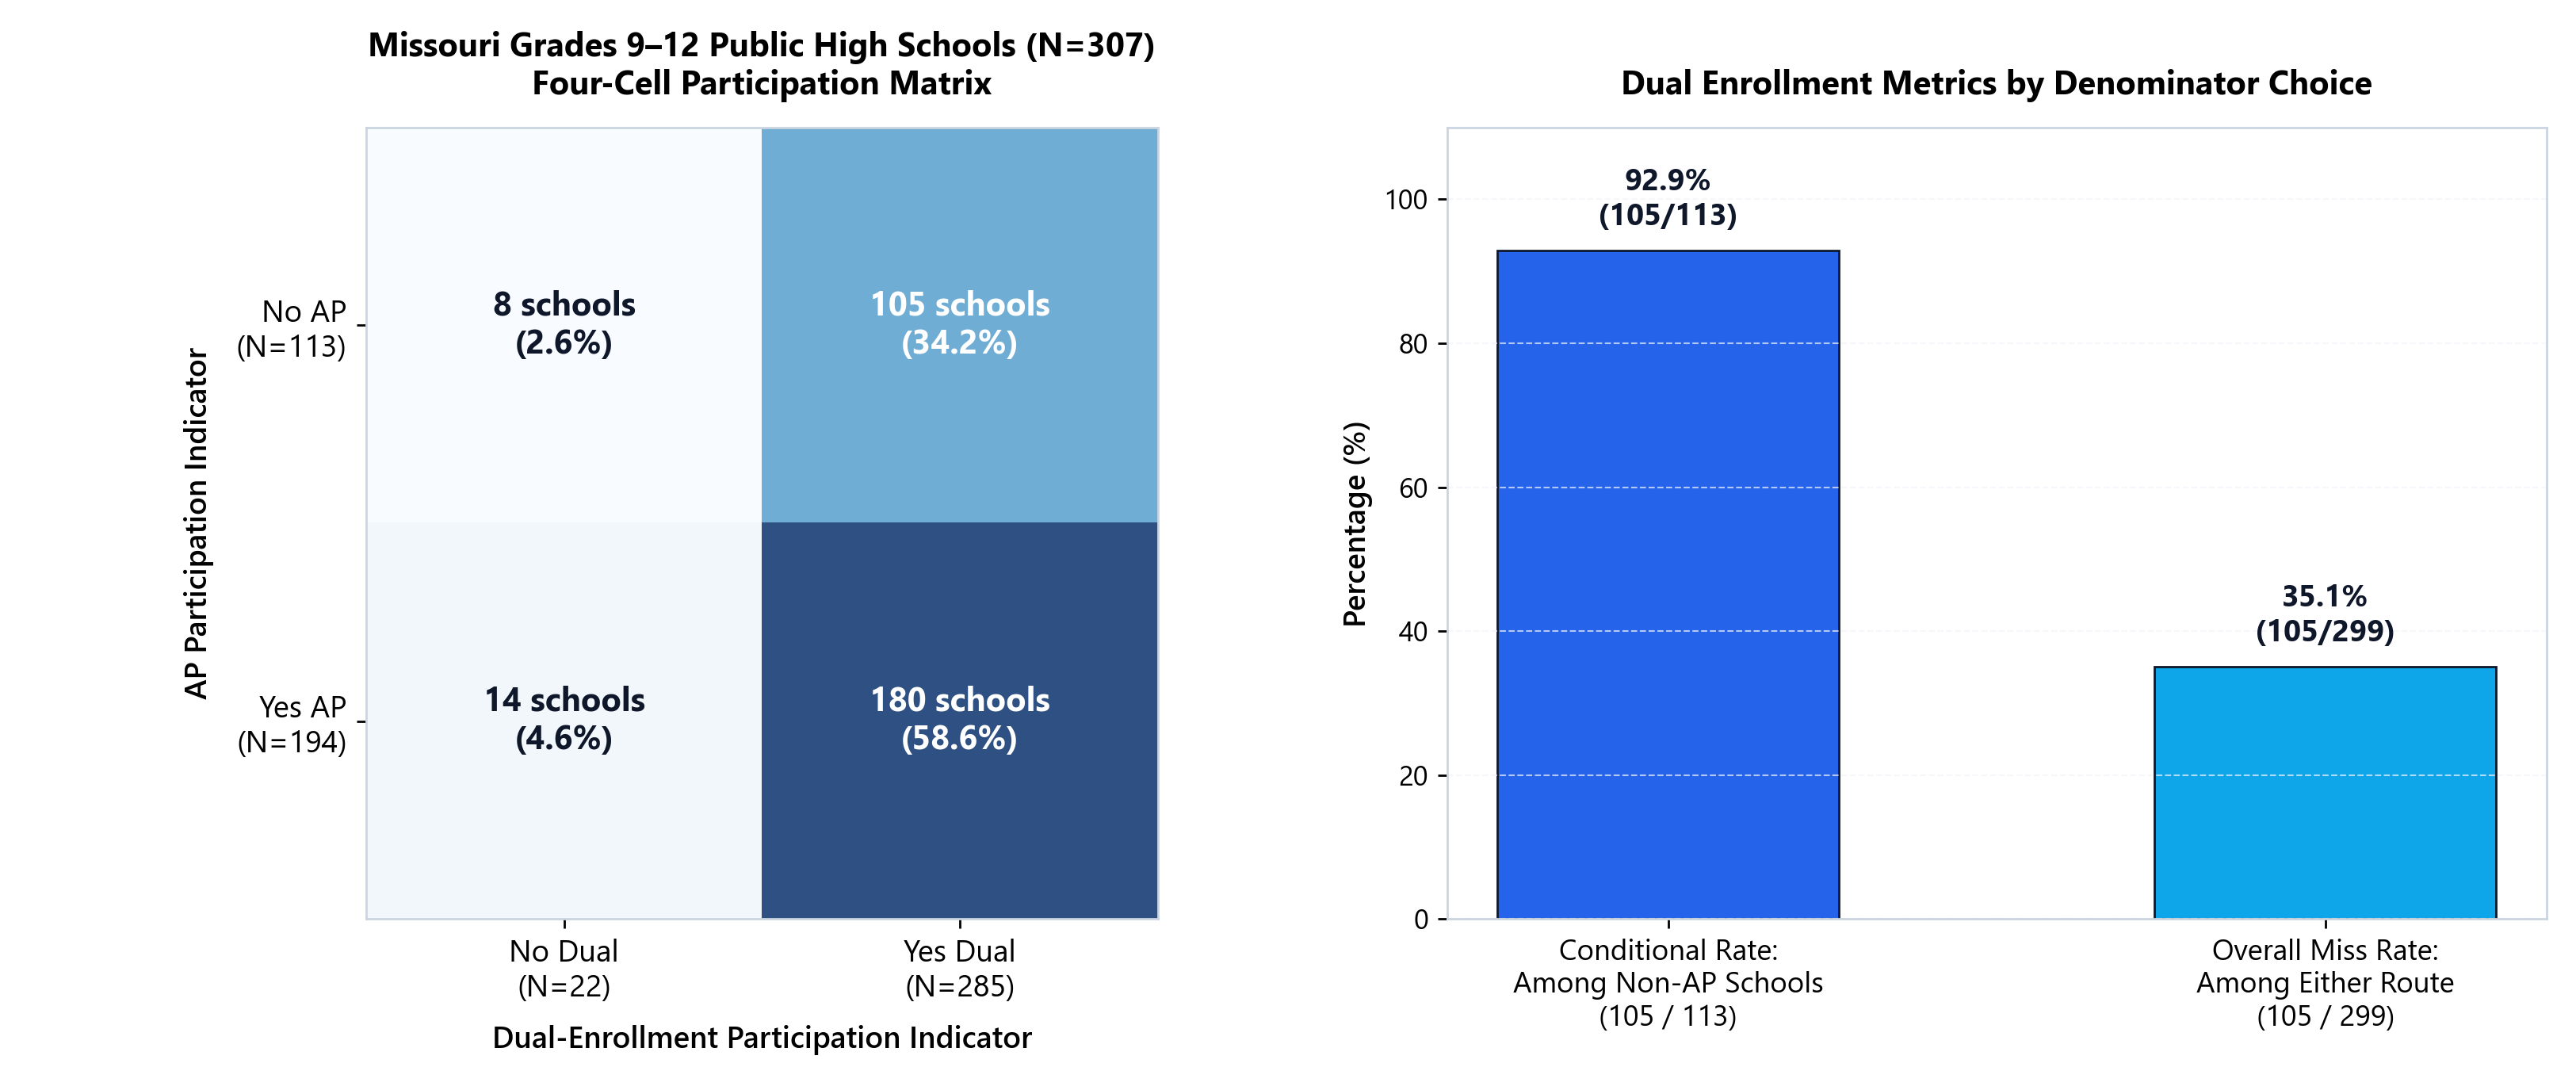

In [5]:
display.Image(filename=str(ARTIFACTS_DIR / "fig1_ap_dual_contingency.png"), width=850)


### Scholarly Interpretation & Epistemic Boundaries
- **Claim Supported**: Of the 113 high schools reporting no AP participation, **92.9%** (105 schools) report student participation in dual enrollment. If evaluated among all 299 schools with either pathway, an AP-only measure misses **35.1%** (105 schools).
- **Boundaries**: 
  - An absence of reported AP and dual enrollment (8 schools, 2.6%) does **not** establish an absence of all college-level pathways (schools may offer International Baccalaureate, career and technical education articulation credits, or local college arrangements not captured under CRDC survey items).
  - This study does **not** evaluate course quality, credit transferability, or student completion benefits.


## 5. Study 2: Curricular Concealment in AP (The Case of Computer Science)

### Motivation
Accountability systems and public scorecards frequently reward high schools for having "an AP Program". But does an umbrella AP indicator guarantee student access across core subject domains, or does it conceal the absence of reported participation in foundational technical fields?

### Narrow Question
> **Among schools reporting AP participation, what percentage reported no AP Computer Science participation?**

### Statistical Path & Calculation
We restrict the sample to high schools reporting `SCH_APENR_IND == 'Yes'` ($N=194$ in the baseline 307 cohort), and calculate the proportion reporting `SCH_APCOMPENR_IND == 'No'`:
$$\text{Concealment Rate}_{\text{AP CS}} = \frac{N(\text{Yes AP} \land \text{No AP CS})}{N(\text{Yes AP})}$$


In [6]:
# Restrict to AP-participating schools
ap_schools_307 = df_307[df_307['ap_participating']].copy()
n_ap_307 = len(ap_schools_307)

n_no_cs_307 = (ap_schools_307['ap_cs_indicator_raw'] == 'No').sum()
n_yes_cs_307 = (ap_schools_307['ap_cs_indicator_raw'] == 'Yes').sum()
pct_no_cs_307 = (n_no_cs_307 / n_ap_307) * 100

print(f"=== STUDY 2: AP COMPUTER SCIENCE REPORTED PARTICIPATION (N={n_ap_307}) ===")
print(f"Schools reporting NO AP Computer Science participation: {n_no_cs_307} ({pct_no_cs_307:.2f}%)")
print(f"Schools reporting YES AP Computer Science participation: {n_yes_cs_307} ({n_yes_cs_307 / n_ap_307 * 100:.2f}%)")

# Sensitivity check on 317
ap_schools_317 = df_317[df_317['ap_participating']].copy()
n_ap_317 = len(ap_schools_317)
n_no_cs_317 = (ap_schools_317['ap_cs_indicator_raw'] == 'No').sum()
pct_no_cs_317 = (n_no_cs_317 / n_ap_317) * 100

print(f"\nSensitivity (317 Sample, N_AP={n_ap_317}):")
print(f"Schools reporting NO AP CS participation: {n_no_cs_317} ({pct_no_cs_317:.2f}%)")
print(f"Difference: {pct_no_cs_317 - pct_no_cs_307:+.2f} percentage points")


=== STUDY 2: AP COMPUTER SCIENCE REPORTED PARTICIPATION (N=194) ===
Schools reporting NO AP Computer Science participation: 127 (65.46%)
Schools reporting YES AP Computer Science participation: 67 (34.54%)

Sensitivity (317 Sample, N_AP=201):
Schools reporting NO AP CS participation: 129 (64.18%)
Difference: -1.28 percentage points


### Visualization: Figure 2
Reported AP Computer Science participation breakdown:


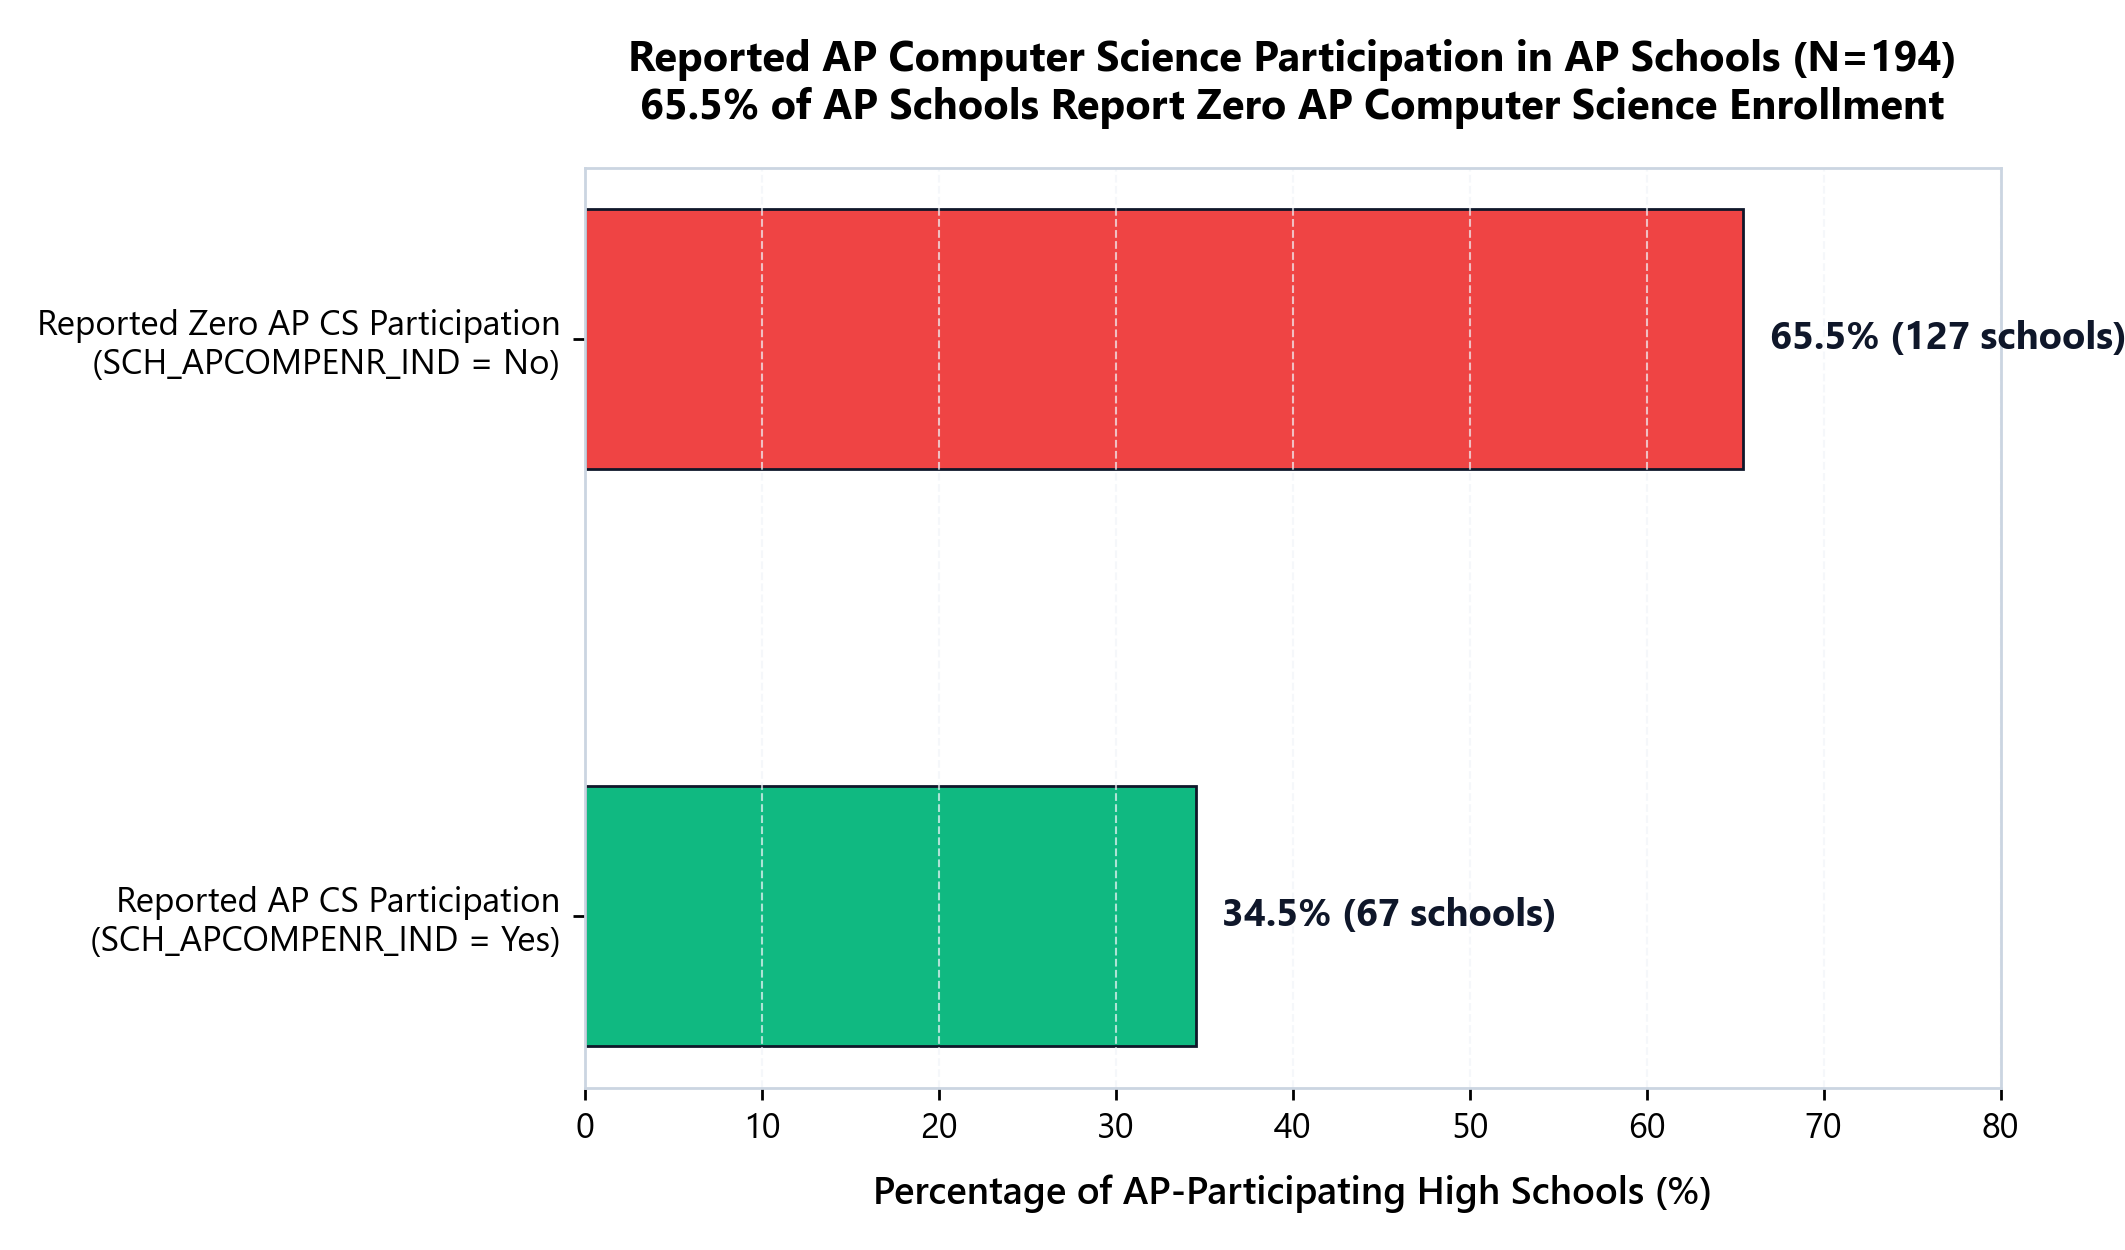

In [7]:
display.Image(filename=str(ARTIFACTS_DIR / "fig2_ap_cs_concealment.png"), width=750)


### Scholarly Interpretation & Epistemic Boundaries
- **Claim Supported**: Among Missouri public high schools actively reporting AP participation, **65.5%** (127 of 194) reported zero student enrollment in AP Computer Science during 2021–22. An umbrella AP label conceals that nearly two-thirds of AP schools report no students taking AP Computer Science.
- **Boundaries**: 
  - This does **not** establish that those schools offered no AP CS courses or pathways in their curriculum catalogs (a course may have been listed but lacked enrolled students).
  - It does not measure student demand, teacher staffing availability, or introductory non-AP computing electives.


## 6. Study 3: The Denominator Wedge (Schools vs. Students in Physics Provision)

### Motivation
A central measurement vulnerability in education policy is confusing **institutional availability** ($P_{\text{school}}$) with **student exposure** ($P_{\text{student}}$). Neither measure inherently "overstates" the other; they describe different populations. The divergence between them provides critical structural information about how educational opportunity scales with institutional size.

### Handling Negative Administrative Codes in CRDC Enrollment
In official CRDC records, student enrollment is disaggregated by sex (`TOT_ENR_M`, `TOT_ENR_F`, `TOT_ENR_X`).
- Negative values are administrative codes, not negative students:
  - `-9` indicates *Not Applicable / Skipped* (nonbinary category not collected or reported by the LEA; 304 of 307 schools).
  - `-12` indicates *Data Suppressed for Privacy Protections* (1 school: Central High School in Kansas City, `291640000840`).
- Summing only released, nonnegative enrollment components yields a **provisional calculation from released counts**, while the single suppressed nonbinary component remains unresolved.

### Narrow Question
> **Does the percentage of schools reporting zero physics classes differ from the percentage of students attending those schools?**

### Statistical Path & Calculation
1. **School-Level Availability ($P_{\text{school}}$)**:
   $$P_{\text{school}} = \frac{1}{N} \sum_{i=1}^N \mathbf{1}(\text{Physics}_i = 0)$$
2. **Student Exposure from Released Counts ($P_{\text{student}}$)**:
   $$P_{\text{student}} = \frac{\sum_{i=1}^N \text{ReleasedEnrollment}_i \cdot \mathbf{1}(\text{Physics}_i = 0)}{\sum_{i=1}^N \text{ReleasedEnrollment}_i}$$
3. **Denominator Wedge / Divergence**:
   $$\Delta = P_{\text{school}} - P_{\text{student}}$$


In [8]:
# 1. School-level percentage
zero_phys_307 = df_307['physics_classes'] == 0
n_zero_schools_307 = zero_phys_307.sum()
school_pct_307 = (n_zero_schools_307 / len(df_307)) * 100

# 2. Student-level percentage from released nonnegative counts
rel_enr_total_307 = df_307['crdc_released_enrollment'].sum()
rel_enr_zero_307 = df_307.loc[zero_phys_307, 'crdc_released_enrollment'].sum()
student_pct_307 = (rel_enr_zero_307 / rel_enr_total_307) * 100

wedge_307 = school_pct_307 - student_pct_307

print("=== STUDY 3: DENOMINATOR DIVERGENCE (BASELINE 307) ===")
print(f"Total High Schools: {len(df_307)}")
print(f"Schools reporting 0 Physics classes: {n_zero_schools_307} ({school_pct_307:.2f}%, exact: {school_pct_307:.4f}%)")
print(f"Released Student Enrollment across 307 schools: {rel_enr_total_307:,.0f}")
print(f"Released Student Enrollment at Zero-Physics schools: {rel_enr_zero_307:,.0f}")
print(f"Student Exposure Percentage: {student_pct_307:.2f}% (exact: {student_pct_307:.4f}%)")
print(f"Denominator Divergence: {wedge_307:.2f} percentage points (exact: {wedge_307:.4f} pp)")

# Institutional scale decomposition
mean_enr_zero = df_307.loc[zero_phys_307, 'crdc_released_enrollment'].mean()
mean_enr_has = df_307.loc[~zero_phys_307, 'crdc_released_enrollment'].mean()
med_enr_zero = df_307.loc[zero_phys_307, 'crdc_released_enrollment'].median()
med_enr_has = df_307.loc[~zero_phys_307, 'crdc_released_enrollment'].median()

print(f"\nInstitutional Enrollment Scale:")
print(f"Zero-Physics Schools: Mean = {mean_enr_zero:.1f}, Median = {med_enr_zero:.0f}")
print(f"Physics-Offering Schools: Mean = {mean_enr_has:.1f}, Median = {med_enr_has:.0f}")


=== STUDY 3: DENOMINATOR DIVERGENCE (BASELINE 307) ===
Total High Schools: 307
Schools reporting 0 Physics classes: 101 (32.90%, exact: 32.8990%)
Released Student Enrollment across 307 schools: 228,637
Released Student Enrollment at Zero-Physics schools: 41,616
Student Exposure Percentage: 18.20% (exact: 18.2018%)
Denominator Divergence: 14.70 percentage points (exact: 14.6972 pp)

Institutional Enrollment Scale:
Zero-Physics Schools: Mean = 412.0, Median = 280
Physics-Offering Schools: Mean = 907.9, Median = 728


### Sensitivity Check: Broad Sample (N=317)


In [9]:
zero_phys_317 = df_317['physics_classes'] == 0
school_pct_317 = zero_phys_317.mean() * 100

rel_enr_total_317 = df_317['crdc_released_enrollment'].sum()
rel_enr_zero_317 = df_317.loc[zero_phys_317, 'crdc_released_enrollment'].sum()
student_pct_317 = (rel_enr_zero_317 / rel_enr_total_317) * 100
wedge_317 = school_pct_317 - student_pct_317

print("=== STUDY 3: SENSITIVITY COMPARISON ===")
print(f"Baseline (307): School = {school_pct_307:.2f}%, Student = {student_pct_307:.2f}%, Divergence = {wedge_307:.2f} pp")
print(f"Sensitivity (317): School = {school_pct_317:.2f}%, Student = {student_pct_317:.2f}%, Divergence = {wedge_317:.2f} pp")
print(f"Difference: {wedge_317 - wedge_307:+.2f} percentage points")


=== STUDY 3: SENSITIVITY COMPARISON ===
Baseline (307): School = 32.90%, Student = 18.20%, Divergence = 14.70 pp
Sensitivity (317): School = 33.12%, Student = 17.85%, Divergence = 15.27 pp
Difference: +0.57 percentage points


### Visualization: Figure 3
The denominator divergence and institutional enrollment scale distribution:


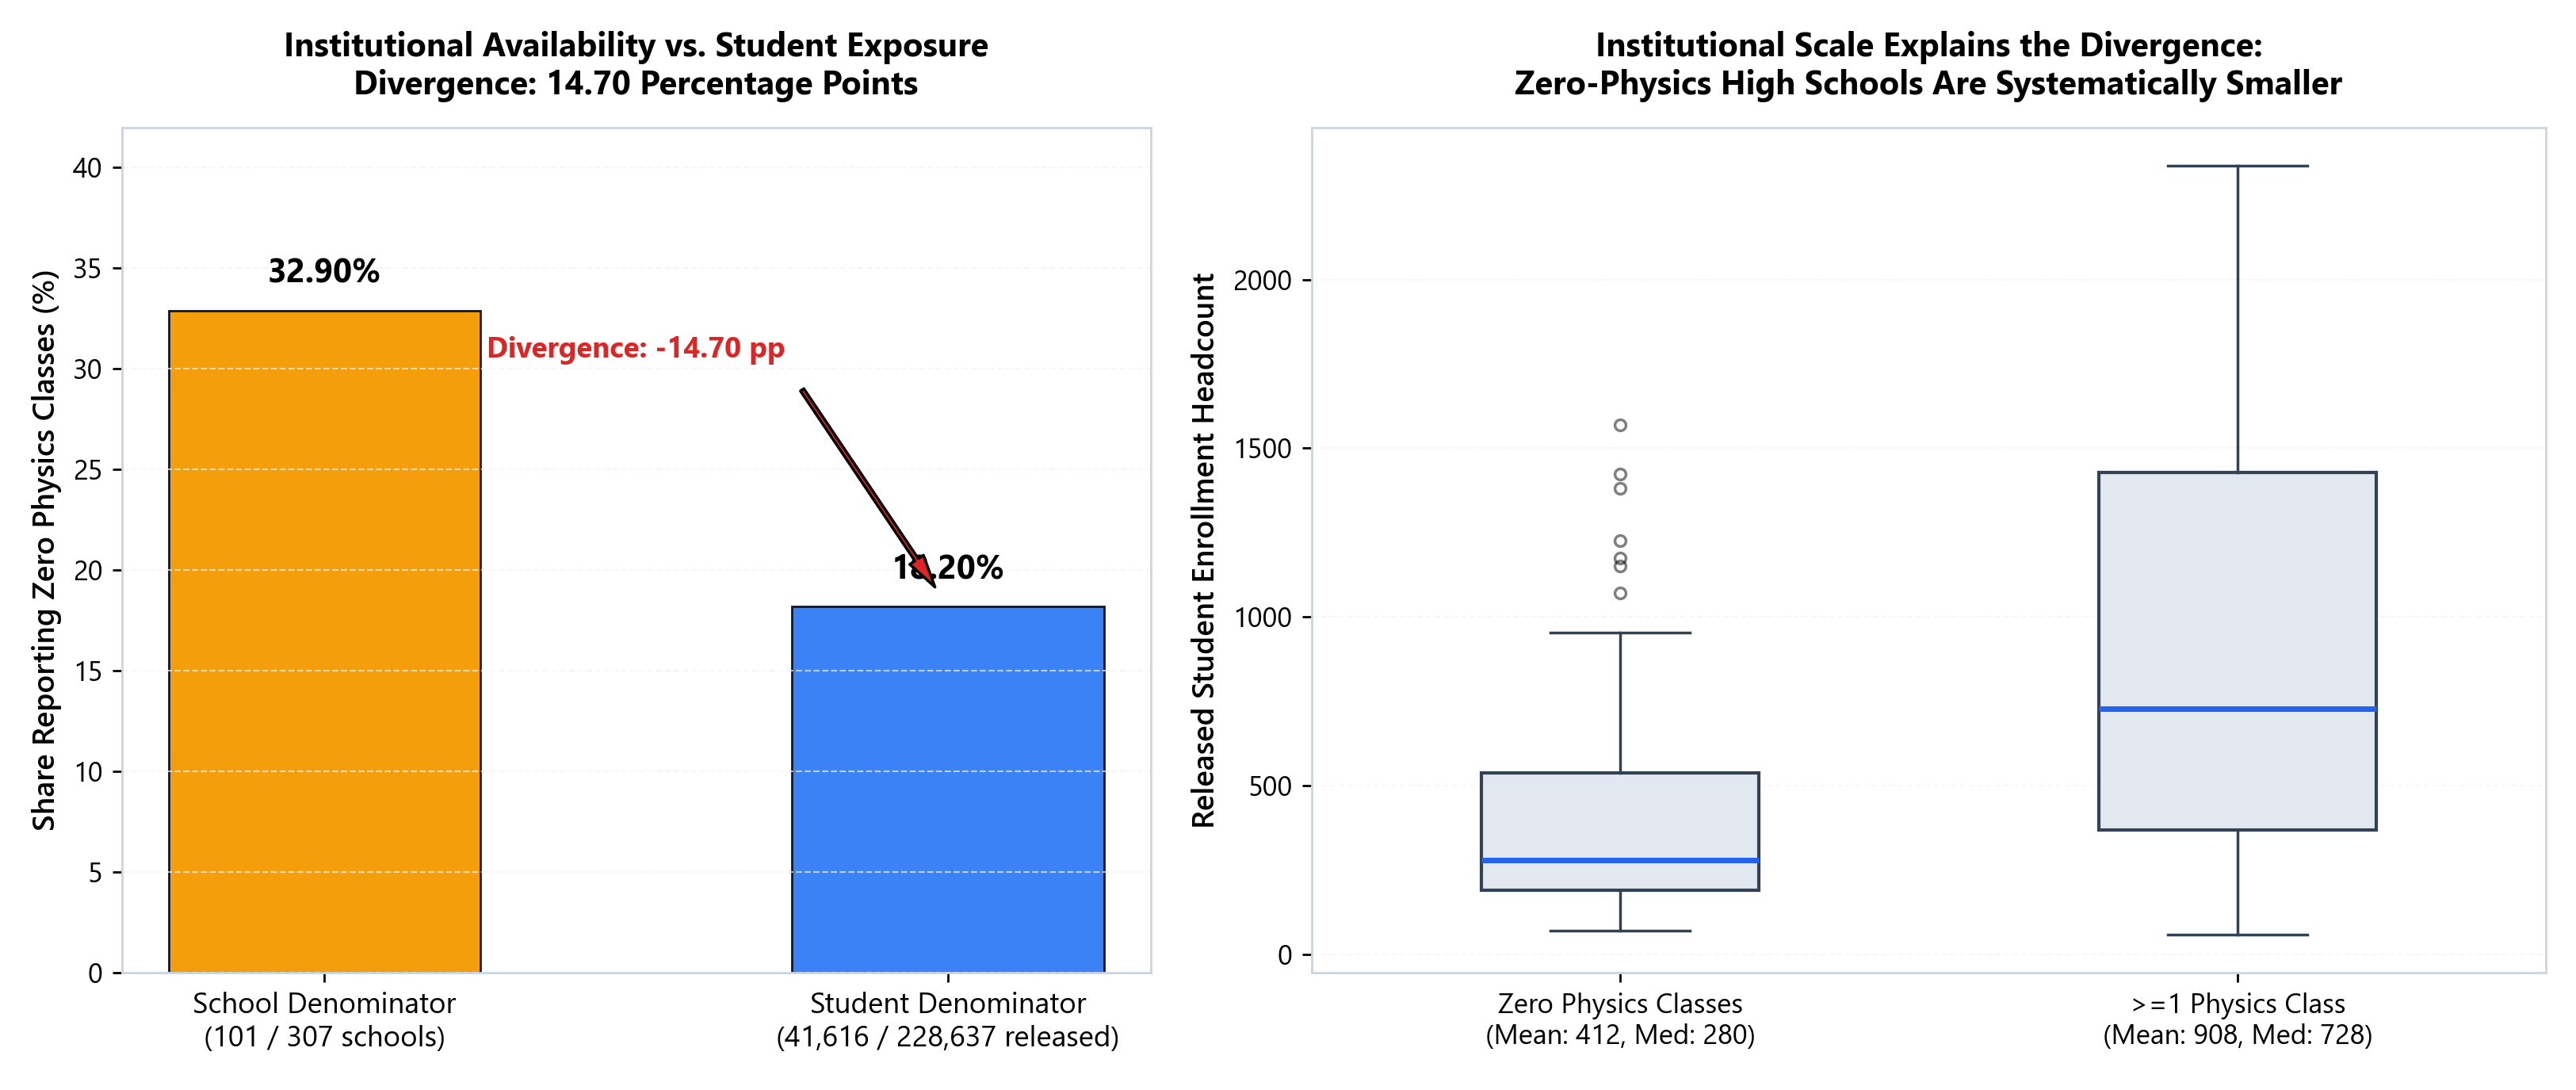

In [10]:
display.Image(filename=str(ARTIFACTS_DIR / "fig3_physics_denominator_wedge.png"), width=900)


### Scholarly Interpretation & Epistemic Boundaries
- **Claim Supported**: The choice of denominator reveals a **14.70 percentage-point divergence**. In Missouri, 32.90% of regular high schools report zero physics classes, but those schools enroll only 18.20% of the state's secondary student body (based on released nonnegative counts).
- **Structural Driver**: High schools reporting zero physics classes are systematically smaller in student body size (mean enrollment 412, median 280) compared to physics-offering high schools (mean enrollment 908, median 728).
- **Boundaries**: 
  - Neither denominator is inherently superior; they answer different questions. School-level counts describe the distribution of course offerings across administrative units; student-level weights describe potential learner exposure.
  - The suppressed nonbinary record (1 school) remains unresolved in public files.
  - Explaining the divergence via rural geography would require a separate NCES locale analysis; here we strictly substantiate that zero-physics schools are smaller in scale.


## 7. Synthesis & Scorecard of Findings

### Master Findings Scorecard

| Study | Core Question | Baseline (N=307) | Sensitivity (N=317) | Delta | Substantive Conclusion |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Study 1 (Metric A)** | Dual Enrollment rate among schools reporting No AP | **92.9%** (105 / 113) | **93.1%** (108 / 116) | +0.18 pp | Among schools with no AP participation, 93% report college-level pathways through dual credit. |
| **Study 1 (Metric B)** | Miss rate of AP indicator among schools with either route | **35.1%** (105 / 299) | **35.0%** (108 / 309) | -0.17 pp | An AP-only measure misses over a third of high schools active in college-level coursework. |
| **Study 2** | Curricular concealment: No AP Computer Science among AP schools | **65.5%** (127 / 194) | **64.2%** (129 / 201) | -1.28 pp | An umbrella AP label conceals that nearly two-thirds of AP high schools report zero AP CS enrollment. |
| **Study 3** | Denominator divergence: School availability vs. Student exposure in Physics | **14.70 pp** (32.90% vs 18.20%) | **15.27 pp** (33.12% vs 17.85%) | +0.57 pp | Institutional availability diverges from student exposure by ~15 pp because zero-physics schools are systematically smaller. |

---

## 8. Epistemic Positioning & Literature Context

These three studies represent **completed descriptive questions**, not speculative causal claims.
- **Prior Research Alignment**: 
  - Nat Malkus (American Enterprise Institute, 2016, 2018) documented that AP course access is systematically constrained by high school scale.
  - The College Board's *AP Program Results* and ACT's dual-enrollment research series (2017, 2020) show that dual credit has expanded rapidly in non-suburban high schools, serving as the primary college-credit vehicle where AP course section scale is unsustainable.
  - OCR's CRDC national summaries frequently report unweighted institutional course gaps alongside student numbers.
- **Exact Contribution**: By establishing an auditable six-point admission rule, this sketchbook explicitly demonstrates how the choice of program indicator (AP vs. Dual) and denominator (institution vs. student) alters the description of secondary educational opportunity.
